### All imports

In [1]:
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.backend import BackendPolicy, backend
from src.layers import ELU, BatchNormalization, Conv1D, Dense, Dropout, GlobalConcatPool1D, LeakyReLU, Softmax
from src.loss.cross_entropy import CrossEntropy
from src.models import Network, Sequential
from src.optimizer import Adam

### Util function for loading and preparing the dataset
The `prepare_har_dataset` function converts raw CSV data into structured, model-ready tensors. It handles the "heavy lifting" such as:
- Reshaping the flat vectors into 3D shape (Samples, Channels, Time Steps)
- Providing Accelerometer and Gyroscope rotation-invariant features as additional channels
- Normalizing the data

The `remap_dataset` is a utility function that allows to filter or re-index the labels for specific experiments (e.g. combining sit and sit-talk into one "sit" class).

In [2]:
def prepare_har_dataset(
    csv_path: str, mode: Literal["raw", "mag", "hybrid"] = "hybrid", shuffle: bool = True
) -> tuple[np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
    """
    Loads the HAR dataset from a CSV file and prepares it for training.
    Args:
        csv_path: Path to the CSV file containing the dataset.
        mode: Determines the type of features to prepare. Options are:
            - 'raw': Use only the raw accelerometer and gyroscope data (6 channels).
            - 'mag': Use only the magnitude of accelerometer and gyroscope data (2 channels).
            - 'hybrid': Use both raw and magnitude features (8 channels).
    """
    raw_data = np.genfromtxt(csv_path, delimiter=",")
    Y = raw_data[:, 9000].astype("int32")
    features_raw = raw_data[:, :9000].astype("float32")
    lengths = raw_data[:, 9001].astype("float32")
    num_samples = features_raw.shape[0]
    time_steps = 1500

    X_6 = np.zeros((num_samples, time_steps, 6), dtype="float32")
    for i in range(6):
        X_6[:, :, i] = features_raw[:, i * time_steps : (i + 1) * time_steps]

    acc_mag = np.linalg.norm(X_6[:, :, 0:3], axis=2, keepdims=True)
    gyro_mag = np.linalg.norm(X_6[:, :, 3:6], axis=2, keepdims=True)

    if mode == "raw":
        X_data = X_6
    elif mode == "mag":
        X_data = np.concatenate([acc_mag, gyro_mag], axis=2)
    else:
        X_data = np.concatenate([X_6, acc_mag, gyro_mag], axis=2)

    num_ch = X_data.shape[2]
    scaler = StandardScaler()
    X_flat = X_data.reshape(-1, num_ch)
    X_scaled_flat = scaler.fit_transform(X_flat)
    X_final = X_scaled_flat.reshape(num_samples, time_steps, num_ch)
    mask = np.arange(time_steps) < lengths[:, None]
    X_final[~mask] = 0.0
    X_final = np.transpose(X_final, (0, 2, 1))
    if shuffle:
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        X_final = X_final[indices]
        Y = Y[indices]
        lengths = lengths[indices]

    return X_final, Y, lengths, scaler


def remap_dataset(
    X: np.ndarray, Y: np.ndarray, lengths: np.ndarray, config: dict[int, str]
) -> tuple[np.ndarray, np.ndarray, np.ndarray, list[str]]:
    """
    Remaps the dataset labels according to the provided configuration.
    Args:
        X: Input features.
        Y: Original labels.
        lengths: Lengths of each sequence.
        config: Mapping of old labels to new labels.
    Returns:
        Remapped features, labels, lengths, and unique labels.
    """
    new_X, new_Y, new_lengths = [], [], []
    unique_labels = sorted(set(config.values()))
    label_to_id = {name: i for i, name in enumerate(unique_labels)}
    for i in range(len(Y)):
        old_id = int(Y[i])
        if old_id in config:
            new_X.append(X[i])
            new_lengths.append(lengths[i])
            new_Y.append(label_to_id[config[old_id]])
    return np.array(new_X), np.array(new_Y), np.array(new_lengths), unique_labels


def prepare_model(labels: list, scaler: StandardScaler, lr: float = 1e-3) -> Network:
    optimizer = Adam(learning_rate=lr)
    loss_fn = CrossEntropy()
    model = Sequential(
        [
            Conv1D(filters=32, kernel_size=31, stride=1, padding=15, name="conv1"),
            BatchNormalization(name="bn1"),
            LeakyReLU(name="leaky_relu1"),
            Conv1D(filters=64, kernel_size=15, stride=2, padding=7, name="conv2"),
            BatchNormalization(name="bn2"),
            LeakyReLU(name="leaky_relu2"),
            Dropout(0.2, name="dropout1"),
            Conv1D(filters=128, kernel_size=7, stride=2, padding=3, name="conv3"),
            BatchNormalization(name="bn3"),
            ELU(name="elu1"),
            GlobalConcatPool1D(name="masked_gap"),
            Dense(128, name="dense1"),
            BatchNormalization(name="bn4"),
            ELU(name="elu2"),
            Dropout(0.5, name="dropout2"),
            Dense(len(labels), name="dense2"),
            Softmax(name="softmax"),
        ]
    )
    model.compile(optimizer=optimizer, loss=loss_fn)
    model.activity_labels = labels
    model.scaler = scaler
    return model

In [3]:
def plot_training_history(history):
    sns.set_style("whitegrid")
    train_losses = history.metrics["train_loss"]
    epochs = range(1, len(train_losses) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    ax1.plot(epochs, train_losses, label="Train Loss", marker="o", markersize=4, alpha=0.7)
    has_val = "val_loss" in history.metrics and len(history.metrics["val_loss"]) > 0
    if has_val:
        val_losses = history.metrics["val_loss"]
        ax1.plot(epochs, val_losses, label="Val Loss", marker="s", markersize=4, color="orange")
        if history.best_epoch is not None:
            best_x = history.best_epoch + 1
            best_y = val_losses[history.best_epoch]
            ax1.axvline(x=best_x, color="red", linestyle="--", alpha=0.6, label="Best Epoch")
            ax1.scatter(best_x, best_y, color="red", marker="*", s=100, zorder=5)

    ax1.set_title("Training and Validation Loss", fontweight="bold")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    if "train_acc" in history.metrics:
        ax2.plot(epochs, history.metrics["train_acc"], label="Train Acc", marker="o", markersize=4, alpha=0.7)

    if "val_acc" in history.metrics and len(history.metrics["val_acc"]) > 0:
        val_accs = history.metrics["val_acc"]
        ax2.plot(epochs, val_accs, label="Val Acc", marker="s", markersize=4, color="green")
        if history.best_epoch is not None:
            best_x = history.best_epoch + 1
            ax2.axvline(x=best_x, color="red", linestyle="--", alpha=0.6, label="Best Epoch")

    ax2.set_title("Training and Validation Accuracy", fontweight="bold")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(x_test, y_test, model, lengths_test, activity_map):
    predictions = model.predict(x_test, mask=lengths_test)
    y_true = np.argmax(y_test, axis=1)
    y_pred = np.argmax(predictions, axis=1)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[activity_map[i] for i in range(num_classes)],
        yticklabels=[activity_map[i] for i in range(num_classes)],
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()


def get_detailed_metrics(y_test, y_pred_probs, activity_map):
    y_true = np.argmax(y_test, axis=1)
    y_pred = np.argmax(y_pred_probs, axis=1)

    report = classification_report(
        y_true,
        y_pred,
        target_names=[activity_map[i] for i in range(len(activity_map))],
        output_dict=True,
        zero_division=0,
    )
    global_metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": report["macro avg"]["f1-score"],
        "Macro Precision": report["macro avg"]["precision"],
        "Macro Recall": report["macro avg"]["recall"],
    }

    df_classes = pd.DataFrame(report).transpose()
    df_classes = df_classes.drop(["macro avg", "weighted avg"], errors="ignore")

    return global_metrics, df_classes


def plot_class_performance(df_classes, metric: Literal["precision", "recall", "f1-score", "support"] = "f1-score"):
    valid_metrics = df_classes.columns.tolist()
    if metric not in valid_metrics:
        raise ValueError(f"Invalid metric '{metric}'. Choose from {valid_metrics}")

    plt.figure(figsize=(12, 8))
    df_sorted = df_classes.sort_values(by=metric, ascending=True)
    colors = sns.color_palette("RdYlGn", len(df_sorted))
    ax = sns.barplot(x=df_sorted[metric], y=df_sorted.index, palette=colors, hue=df_sorted.index, legend=False)
    mean_val = df_sorted[metric].mean()
    plt.axvline(x=mean_val, color="blue", linestyle="--", label=f"Mean {metric.capitalize()} ({mean_val:.2f})")
    plt.title(f"{metric.capitalize()} per Activity", fontsize=15, fontweight="bold")
    plt.xlabel(metric.capitalize())
    plt.ylabel("Activity")
    if metric != "support":
        plt.xlim(0, 1.05)

    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_most_confused_classes(df_classes, top_n=5):
    df_classes["error_rate"] = 1 - df_classes["recall"]
    df_err = df_classes.sort_values(by="error_rate", ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    ax = sns.barplot(x=df_err["error_rate"], y=df_err.index, palette="Reds_r", hue=df_err.index, legend=False)

    ax.bar_label(ax.containers[0], fmt=lambda x: f"{x * 100:.1f}%", padding=8, fontweight="bold", fontsize=11)

    plt.title(f"Top {top_n} Most Confused Activities (By Total Misses)", fontsize=15, fontweight="bold")
    plt.xlabel("Error Rate (1 - Recall)")
    plt.ylabel("Activity")
    plt.xlim(0, 1.1)

    plt.tight_layout()
    plt.show()


def plot_top_mutual_confusions(y_test, y_pred_probs, activity_map, top_n=10):
    y_true = np.argmax(y_test, axis=1)
    y_pred = np.argmax(y_pred_probs, axis=1)

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    mutual_confusions = []
    num_classes = len(activity_map)
    for i in range(num_classes):
        for j in range(i + 1, num_classes):
            combined_error = cm_norm[i, j] + cm_norm[j, i]

            mutual_confusions.append(
                {"Class_A": activity_map[i], "Class_B": activity_map[j], "Mutual_Error": combined_error}
            )

    mutual_df = pd.DataFrame(mutual_confusions).sort_values(by="Mutual_Error", ascending=False).head(top_n)
    mutual_df["Pair"] = mutual_df["Class_A"] + " ↔ " + mutual_df["Class_B"]
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    ax = sns.barplot(x="Mutual_Error", y="Pair", data=mutual_df, palette="viridis", hue="Pair", legend=False)
    ax.bar_label(ax.containers[0], fmt="%.2f", padding=8, fontweight="bold")
    plt.title(f"Top {top_n} Fundamentally Entangled Activities", fontsize=15, fontweight="bold")
    plt.xlabel("Total Mutual Confusion (Sum of Bidirectional Normalized Error)")
    plt.xlim(0, max(mutual_df["Mutual_Error"]) * 1.2)
    plt.tight_layout()
    plt.show()

In [4]:
dataset_path = r"data\KU-HAR_v1.0_raw_samples.csv"
activity_map = {
    0: "Stand",
    1: "Sit",
    2: "Talk-sit",
    3: "Talk-stand",
    4: "Stand-sit",
    5: "Lay",
    6: "Lay-stand",
    7: "Pick",
    8: "Jump",
    9: "Push-up",
    10: "Sit-up",
    11: "Walk",
    12: "Walk-backward",
    13: "Walk-circle",
    14: "Run",
    15: "Stair-up",
    16: "Stair-down",
    17: "Table-tennis",
}
num_classes = len(activity_map)
backend.configure(policy=BackendPolicy(use_gpu=True), dataset_bytes=1024 * 1024 * 1024 * 1024)

2026-03-28 18:26:41,383 | INFO | src.backend | GPU requested. Dataset size: 1099511627776 bytes. Minimum for GPU: 8000000 bytes.
2026-03-28 18:26:41,820 | INFO | src.backend | CuPy available: True.
2026-03-28 18:26:41,821 | INFO | src.backend | Using backend: cupy


# 1. Neural network evaluation (raw)

In [5]:
X_RAW, Y_RAW, LENGHTS_RAW, SCALER_RAW = prepare_har_dataset(dataset_path, mode="raw", shuffle=True)

In [6]:
X_temp, X_raw_test, Y_temp, Y_raw_test, lengths_temp, lengths_raw_test = train_test_split(
    X_RAW, Y_RAW, LENGHTS_RAW, test_size=0.2, random_state=2
)


X_raw_train, X_raw_val, Y_raw_train, Y_raw_val, lengths_raw_train, lengths_raw_val = train_test_split(
    X_temp, Y_temp, lengths_temp, test_size=0.25, random_state=2
)
labels_raw = [activity_map[i] for i in range(num_classes)]
Y_raw_train = np.eye(num_classes)[Y_raw_train.astype(int)]
Y_raw_val = np.eye(num_classes)[Y_raw_val.astype(int)]
Y_raw_test = np.eye(num_classes)[Y_raw_test.astype(int)]

In [7]:
model = prepare_model(labels=labels_raw, scaler=SCALER_RAW)

history, total_time = model.fit(
    x_train=X_raw_train,
    y_train=Y_raw_train,
    x_val=X_raw_val,
    y_val=Y_raw_val,
    epochs=150,
    batch_size=256,
    verbose=2,
    mask=lengths_raw_train,
    val_mask=lengths_raw_val,
    lr_decay_epochs=30,
    lr_decay=0.75,
    early_stopping_patience=15,
    early_stopping_min_delta=1e-3,
)

model.save(r"models\har_model_raw_v0.nnp")

Epoch 1/150, 3.24s/epoch - ETA: 00:08:05
Loss: 2.384431, Acc: 0.2793
Val Loss: 1.729637 - Val Acc: 0.4491
Epoch 3/150, 2.76s/epoch - ETA: 00:07:11
Loss: 1.278438, Acc: 0.5643
Val Loss: 1.104793 - Val Acc: 0.6336
Epoch 5/150, 2.74s/epoch - ETA: 00:06:55
Loss: 0.918462, Acc: 0.6863
Val Loss: 0.809358 - Val Acc: 0.7137
Epoch 7/150, 2.75s/epoch - ETA: 00:06:44
Loss: 0.692049, Acc: 0.7543
Val Loss: 0.614218 - Val Acc: 0.7616
Epoch 9/150, 2.72s/epoch - ETA: 00:06:36
Loss: 0.553325, Acc: 0.8002
Val Loss: 0.604261 - Val Acc: 0.7485
Epoch 11/150, 2.75s/epoch - ETA: 00:06:29
Loss: 0.469118, Acc: 0.8234
Val Loss: 0.511701 - Val Acc: 0.7844
Epoch 13/150, 2.70s/epoch - ETA: 00:06:22
Loss: 0.423542, Acc: 0.8394
Val Loss: 0.461212 - Val Acc: 0.7986
Epoch 15/150, 2.74s/epoch - ETA: 00:06:15
Loss: 0.368978, Acc: 0.8605
Val Loss: 0.495060 - Val Acc: 0.7948
Epoch 17/150, 2.75s/epoch - ETA: 00:06:09
Loss: 0.347540, Acc: 0.8650
Val Loss: 0.451562 - Val Acc: 0.8122
Epoch 19/150, 2.77s/epoch - ETA: 00:06:03


In [8]:
print(f"Total training time: {total_time:.2f} seconds")
for metric_name, values in history.metrics.items():
    print(f"{metric_name}: {values}")

Total training time: 140.77 seconds
train_loss: [2.3844308853149414, 1.5822488069534302, 1.2784382104873657, 1.0712754726409912, 0.918461799621582, 0.7877549529075623, 0.6920486688613892, 0.6125873923301697, 0.5533245801925659, 0.4988575875759125, 0.46911805868148804, 0.4386880397796631, 0.42354199290275574, 0.39262381196022034, 0.36897847056388855, 0.36305102705955505, 0.3475398123264313, 0.33929643034935, 0.32171082496643066, 0.3132810890674591, 0.2936478853225708, 0.2911657691001892, 0.28719085454940796, 0.27979776263237, 0.27117472887039185, 0.26259857416152954, 0.260934054851532, 0.2579139471054077, 0.2543033957481384, 0.24917533993721008, 0.2472737431526184, 0.23874440789222717, 0.23144493997097015, 0.23173466324806213, 0.23106876015663147, 0.2300858348608017, 0.22513914108276367, 0.2185373157262802, 0.22292353212833405, 0.21884091198444366, 0.22003887593746185, 0.21328803896903992, 0.2095533013343811, 0.2120348960161209, 0.20810894668102264, 0.20818862318992615, 0.21333447098731

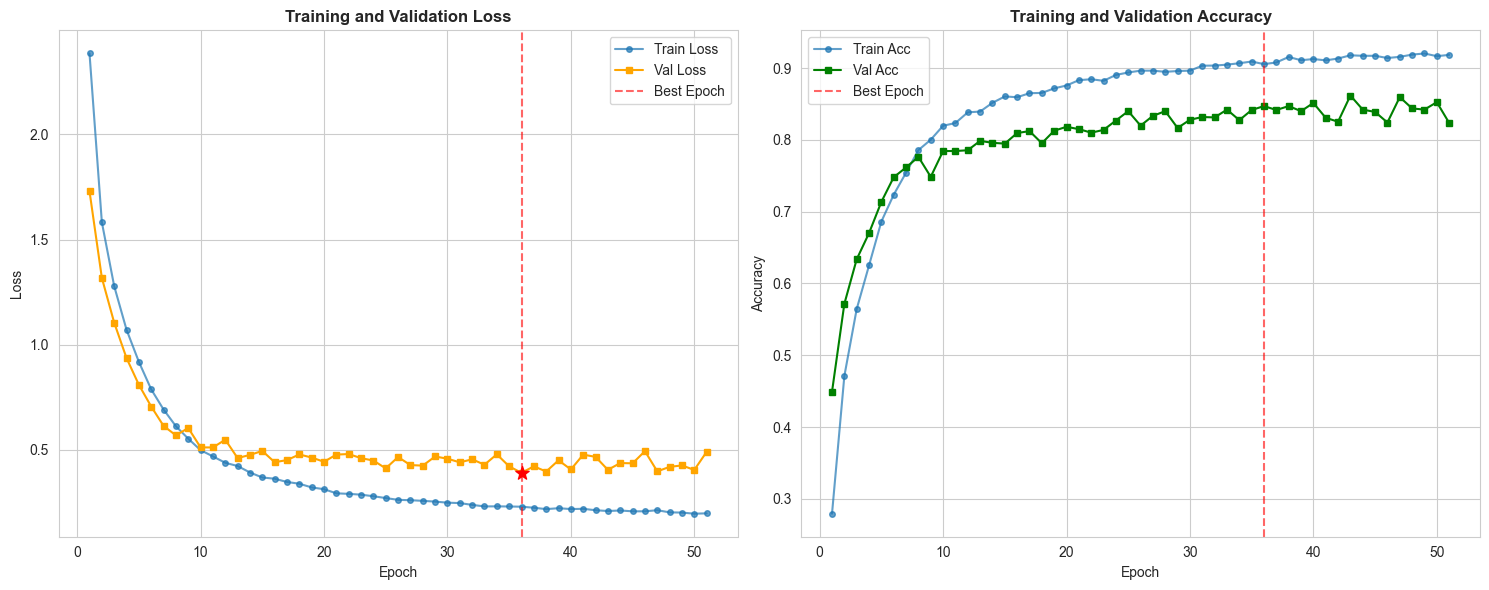

In [9]:
plot_training_history(history)

## 1.1 Evaluation

### 1.1.1 Confisuion matrix

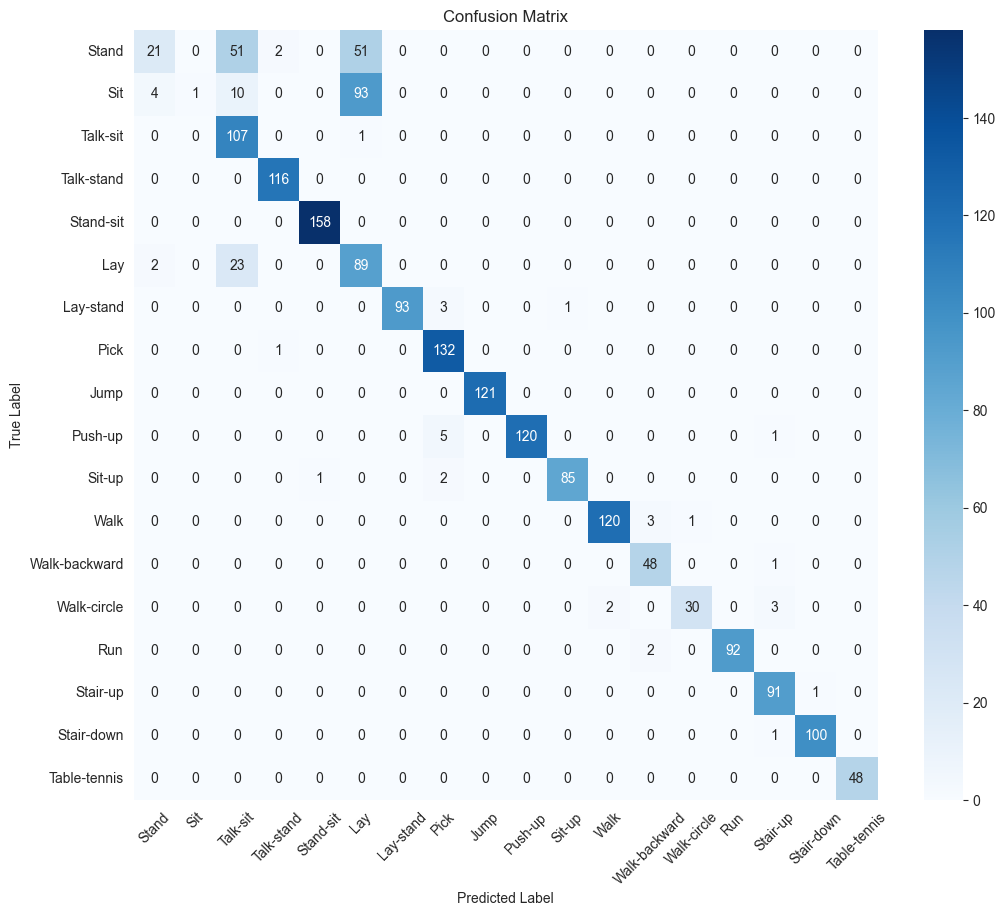

In [10]:
plot_confusion_matrix(X_raw_test, Y_raw_test, model, lengths_test=lengths_raw_test, activity_map=model.activity_labels)

### 1.1.2 Metrics per activity

In [11]:
predictions = model.predict(X_raw_test, mask=lengths_raw_test)
global_m, class_df = get_detailed_metrics(Y_raw_test, predictions, activity_map)

### 1.1.2.1 F1-score

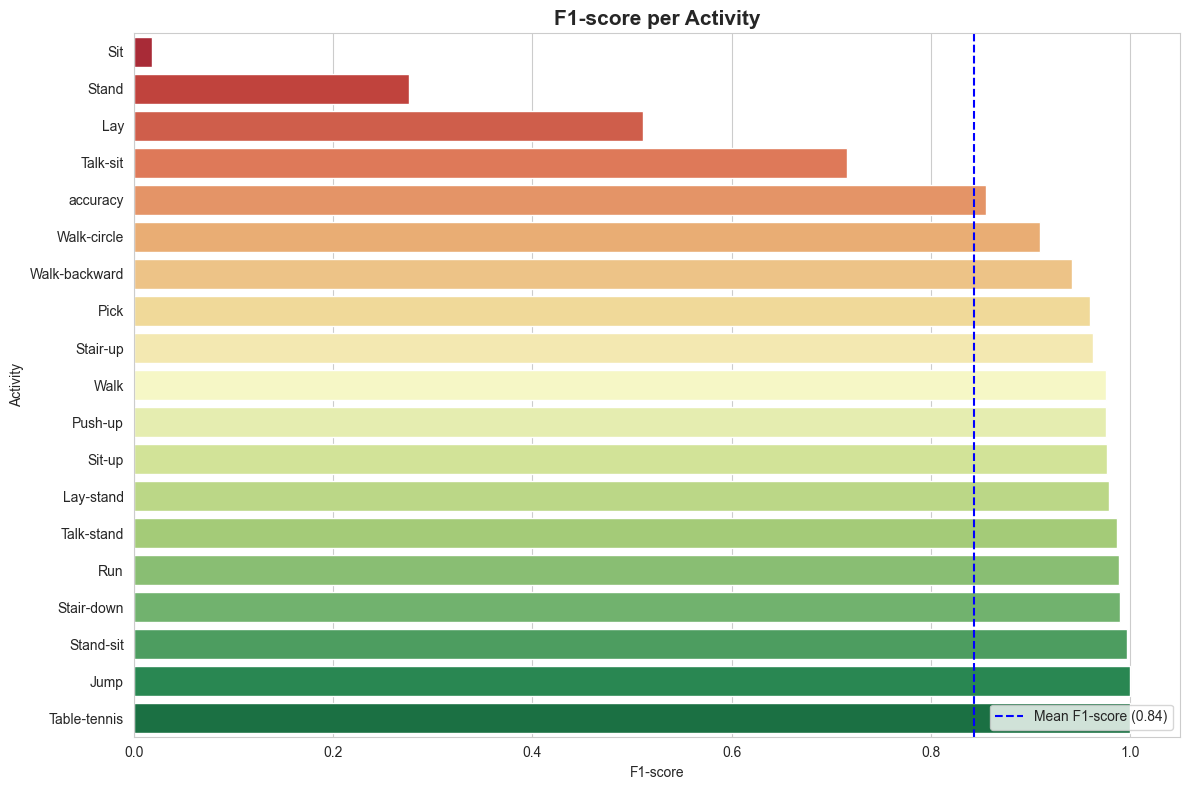

In [12]:
plot_class_performance(class_df, metric="f1-score")

### 1.1.2.2 Recall

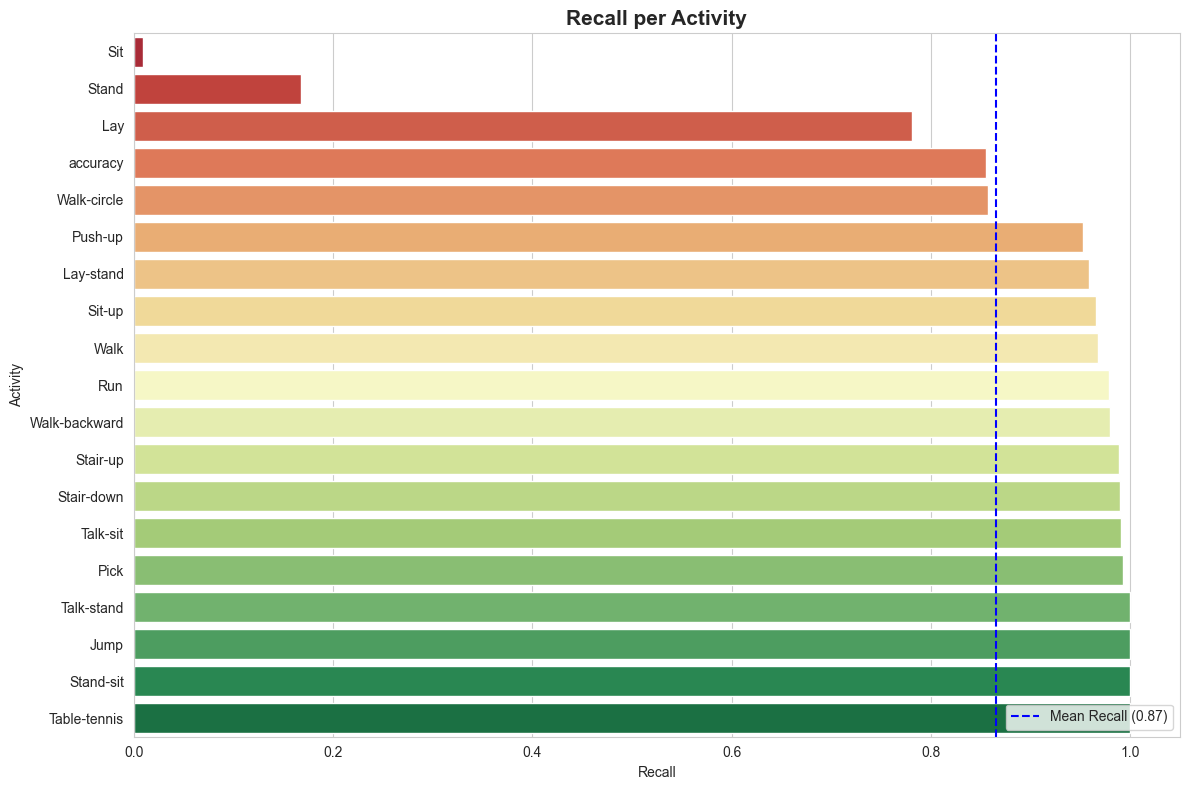

In [13]:
plot_class_performance(class_df, metric="recall")

### 1.1.2.3 Precision

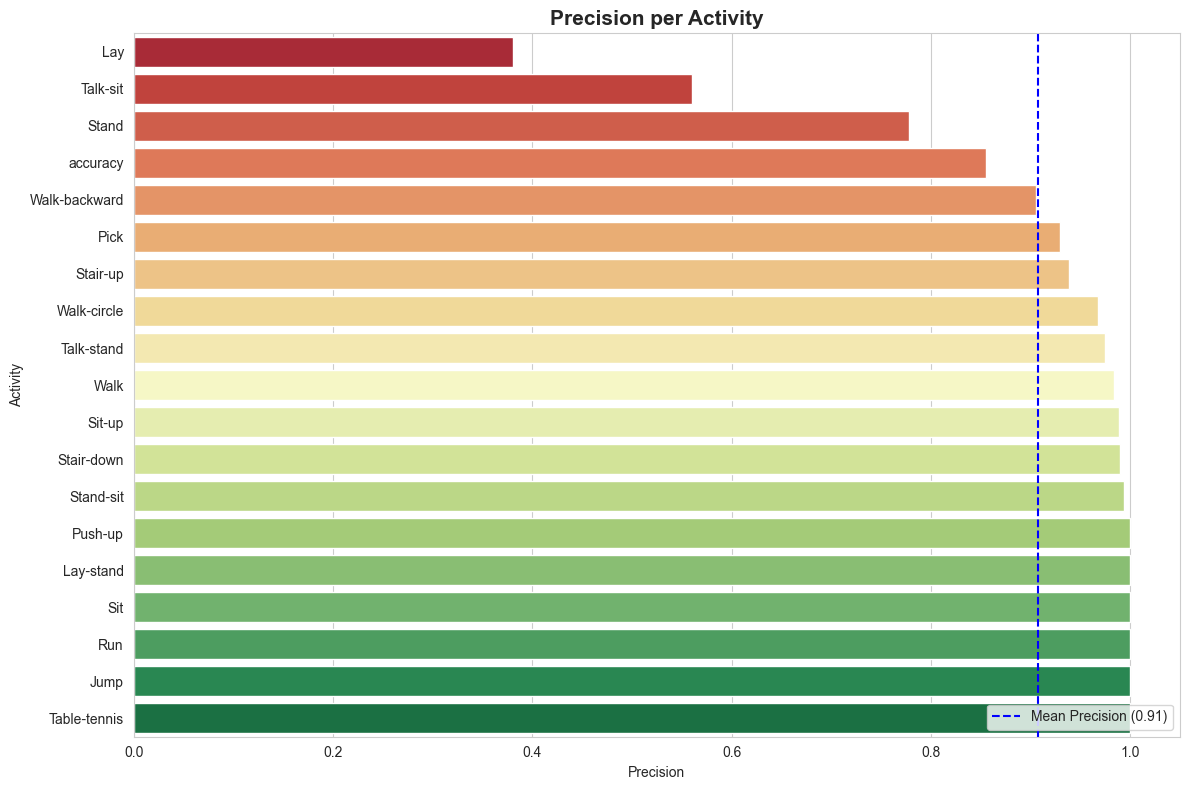

In [14]:
plot_class_performance(class_df, metric="precision")

### 1.1.2.4 Top confused classes by total misses

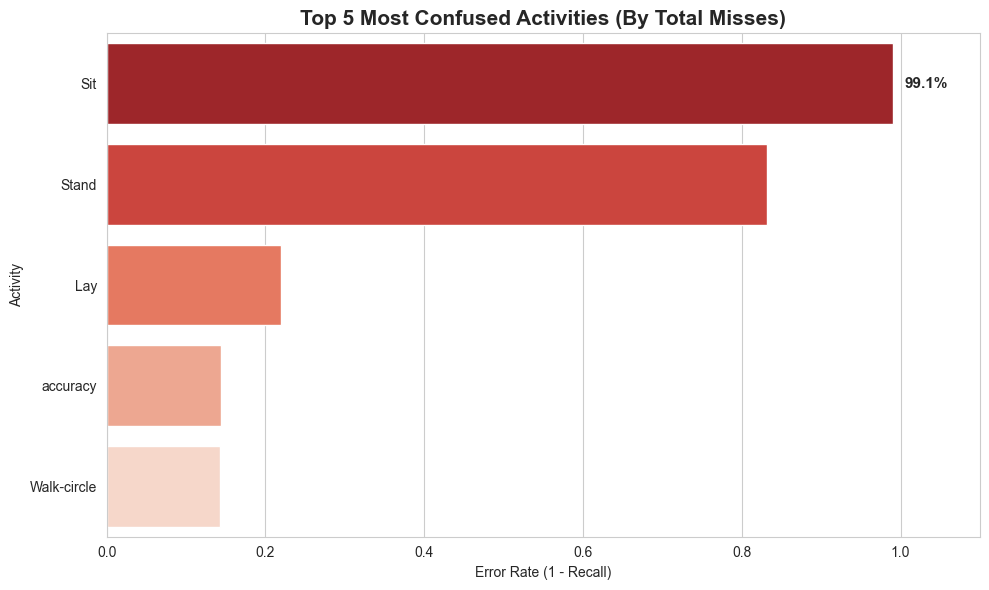

In [15]:
plot_most_confused_classes(class_df, top_n=5)

### 1.1.2.5 Top mutually confused classes

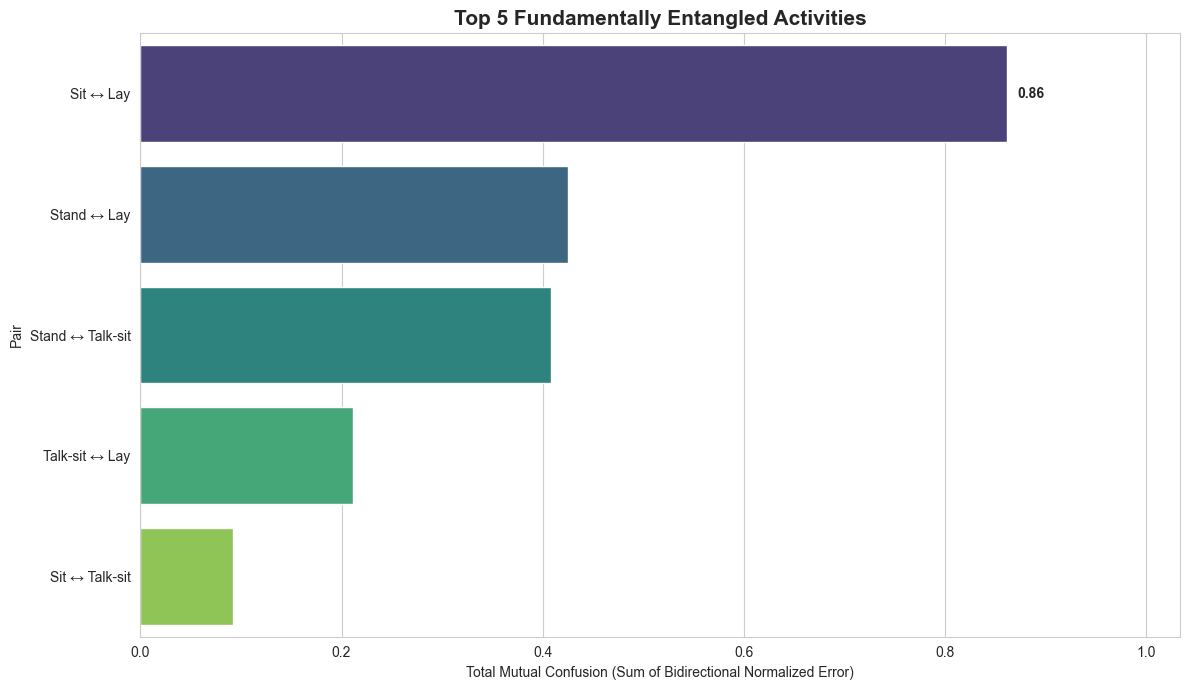

In [16]:
plot_top_mutual_confusions(Y_raw_test, predictions, activity_map, top_n=5)

# 2. Neural network evaluation with the original 18 classes (magnitude)

In [5]:
X_MAGNITUDE, Y_MAGNITUDE, LENGHTS_MAGNITUDE, SCALER_MAGNITUDE = prepare_har_dataset(
    dataset_path, mode="mag", shuffle=True
)

In [6]:
X_temp, X_magnitude_test, Y_temp, Y_magnitude_test, lengths_temp, lengths_magnitude_test = train_test_split(
    X_MAGNITUDE, Y_MAGNITUDE, LENGHTS_MAGNITUDE, test_size=0.2, random_state=2
)


(
    X_magnitude_train,
    X_magnitude_val,
    Y_magnitude_train,
    Y_magnitude_val,
    lengths_magnitude_train,
    lengths_magnitude_val,
) = train_test_split(X_temp, Y_temp, lengths_temp, test_size=0.25, random_state=2)
labels_magnitude = [activity_map[i] for i in range(num_classes)]
Y_magnitude_train = np.eye(num_classes)[Y_magnitude_train.astype(int)]
Y_magnitude_val = np.eye(num_classes)[Y_magnitude_val.astype(int)]
Y_magnitude_test = np.eye(num_classes)[Y_magnitude_test.astype(int)]

In [8]:
model_mag = prepare_model(labels=labels_magnitude, scaler=SCALER_MAGNITUDE)

history_mag, total_time = model_mag.fit(
    x_train=X_magnitude_train,
    y_train=Y_magnitude_train,
    x_val=X_magnitude_val,
    y_val=Y_magnitude_val,
    epochs=150,
    batch_size=256,
    verbose=2,
    mask=lengths_magnitude_train,
    val_mask=lengths_magnitude_val,
    lr_decay_epochs=30,
    lr_decay=0.75,
    early_stopping_patience=15,
    early_stopping_min_delta=1e-3,
)

model_mag.save(r"models\har_model_magnitude_v0.nnp")

Epoch 1/150, 2.97s/epoch - ETA: 00:07:25
Loss: 2.497570, Acc: 0.2290
Val Loss: 1.835559 - Val Acc: 0.3462
Epoch 3/150, 2.42s/epoch - ETA: 00:06:25
Loss: 1.598764, Acc: 0.4230
Val Loss: 1.345783 - Val Acc: 0.5046
Epoch 5/150, 2.43s/epoch - ETA: 00:06:09
Loss: 1.336821, Acc: 0.5132
Val Loss: 1.193507 - Val Acc: 0.5389
Epoch 7/150, 2.40s/epoch - ETA: 00:05:59
Loss: 1.168095, Acc: 0.5689
Val Loss: 0.990788 - Val Acc: 0.6010
Epoch 9/150, 2.43s/epoch - ETA: 00:05:52
Loss: 1.028650, Acc: 0.6191
Val Loss: 0.928725 - Val Acc: 0.6336
Epoch 11/150, 2.38s/epoch - ETA: 00:05:44
Loss: 0.915298, Acc: 0.6491
Val Loss: 0.942266 - Val Acc: 0.6375
Epoch 13/150, 2.43s/epoch - ETA: 00:05:38
Loss: 0.822084, Acc: 0.6810
Val Loss: 0.892828 - Val Acc: 0.6396
Epoch 15/150, 2.43s/epoch - ETA: 00:05:33
Loss: 0.753783, Acc: 0.7017
Val Loss: 0.790822 - Val Acc: 0.6783
Epoch 17/150, 2.44s/epoch - ETA: 00:05:27
Loss: 0.672011, Acc: 0.7351
Val Loss: 0.723277 - Val Acc: 0.7131
Epoch 19/150, 2.44s/epoch - ETA: 00:05:22


In [10]:
print(f"Total training time: {total_time:.2f} seconds")
for metric_name, values in history_mag.metrics.items():
    print(f"{metric_name}: {values}")

Total training time: 291.69 seconds
train_loss: [2.4975695610046387, 1.8454313278198242, 1.5987635850906372, 1.4477787017822266, 1.3368209600448608, 1.233445167541504, 1.1680951118469238, 1.0843013525009155, 1.0286496877670288, 0.9630818367004395, 0.9152984023094177, 0.8623543977737427, 0.8220840692520142, 0.7856898307800293, 0.7537833452224731, 0.7149133086204529, 0.6720105409622192, 0.6495071053504944, 0.6231622099876404, 0.6130136251449585, 0.588437557220459, 0.5690962672233582, 0.5468704104423523, 0.5238864421844482, 0.5111331343650818, 0.4954789876937866, 0.4942304193973541, 0.47052156925201416, 0.46514496207237244, 0.4537571668624878, 0.44424134492874146, 0.4544954299926758, 0.44621896743774414, 0.44457578659057617, 0.4395805299282074, 0.43491750955581665, 0.4188542664051056, 0.4116552174091339, 0.41055959463119507, 0.4105263948440552, 0.39916348457336426, 0.39815691113471985, 0.3828301727771759, 0.3875564634799957, 0.3844827115535736, 0.37822845578193665, 0.3761056959629059, 0.3

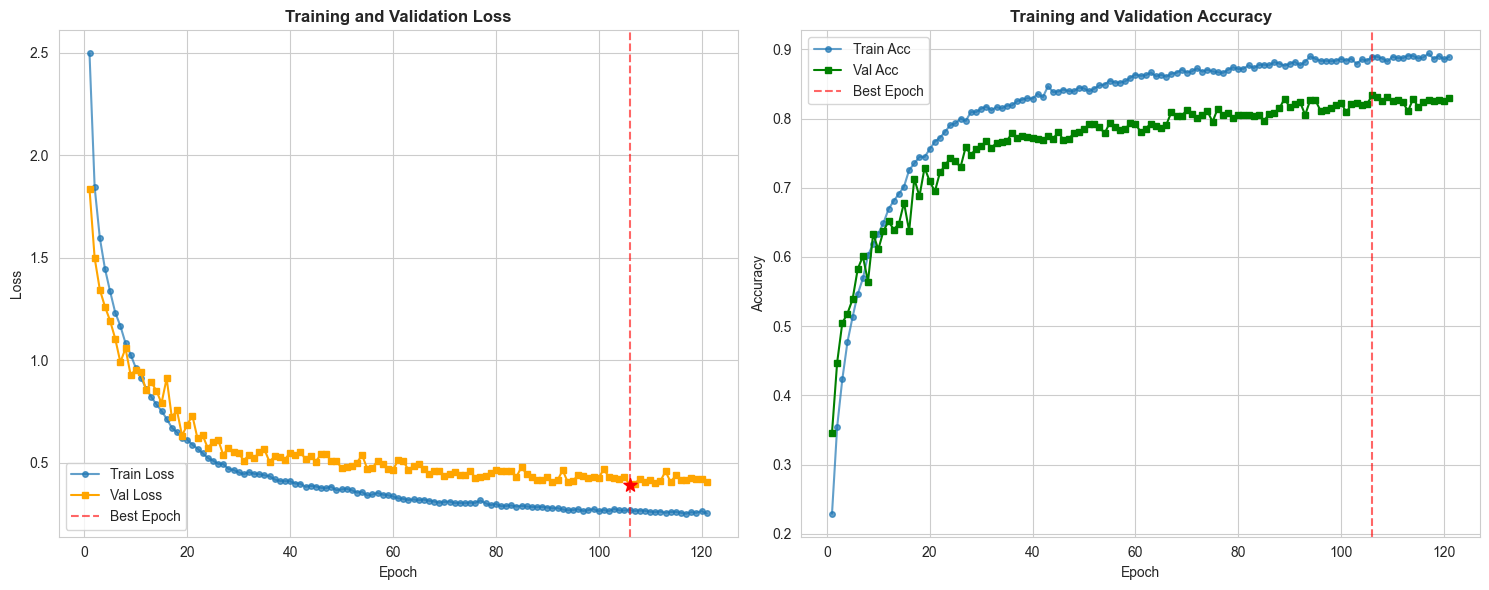

In [11]:
plot_training_history(history_mag)

## 2.1 Evaluation

In [12]:
model_mag = Network.load(r"models\har_model_magnitude_v0.nnp")

### 2.1.1 Confisuion matrix

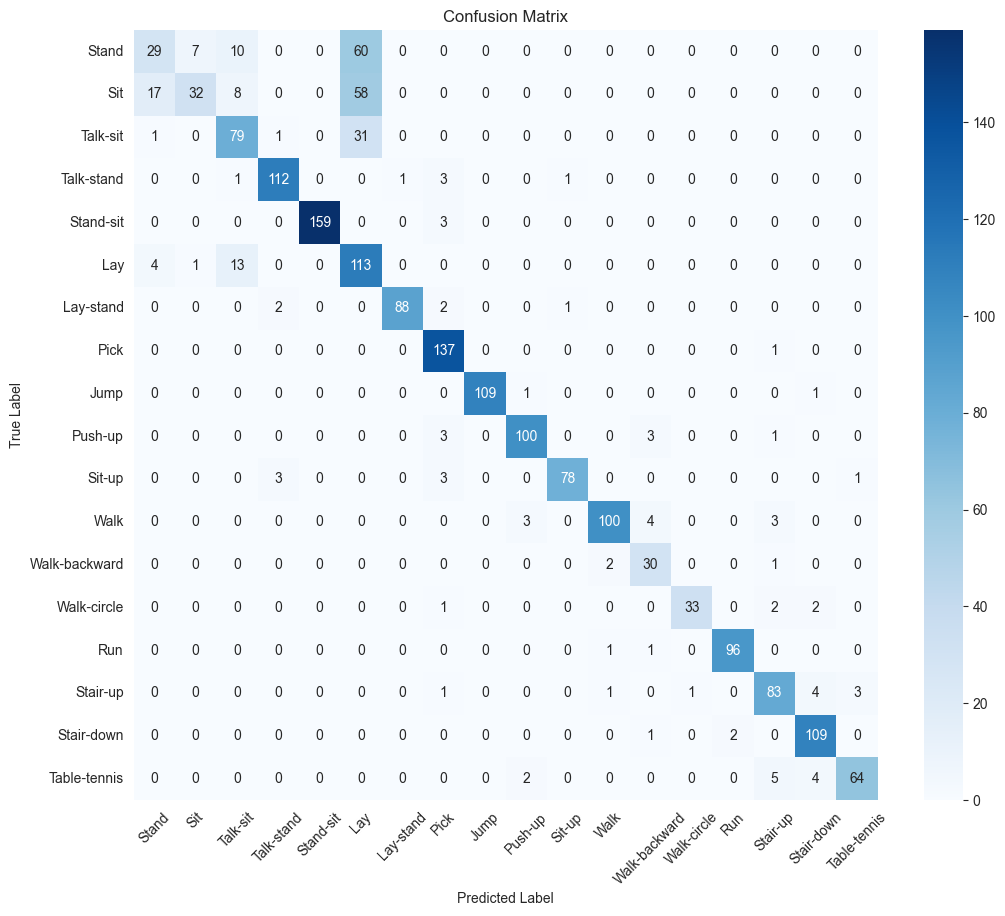

In [15]:
plot_confusion_matrix(
    X_magnitude_test,
    Y_magnitude_test,
    model_mag,
    lengths_test=lengths_magnitude_test,
    activity_map=model_mag.activity_labels,
)

### 2.1.2 Metrics per activity

In [16]:
predictions = model_mag.predict(X_magnitude_test, mask=lengths_magnitude_test)
global_m, class_df = get_detailed_metrics(Y_magnitude_test, predictions, activity_map=model_mag.activity_labels)

### 2.1.2.1 F1-score

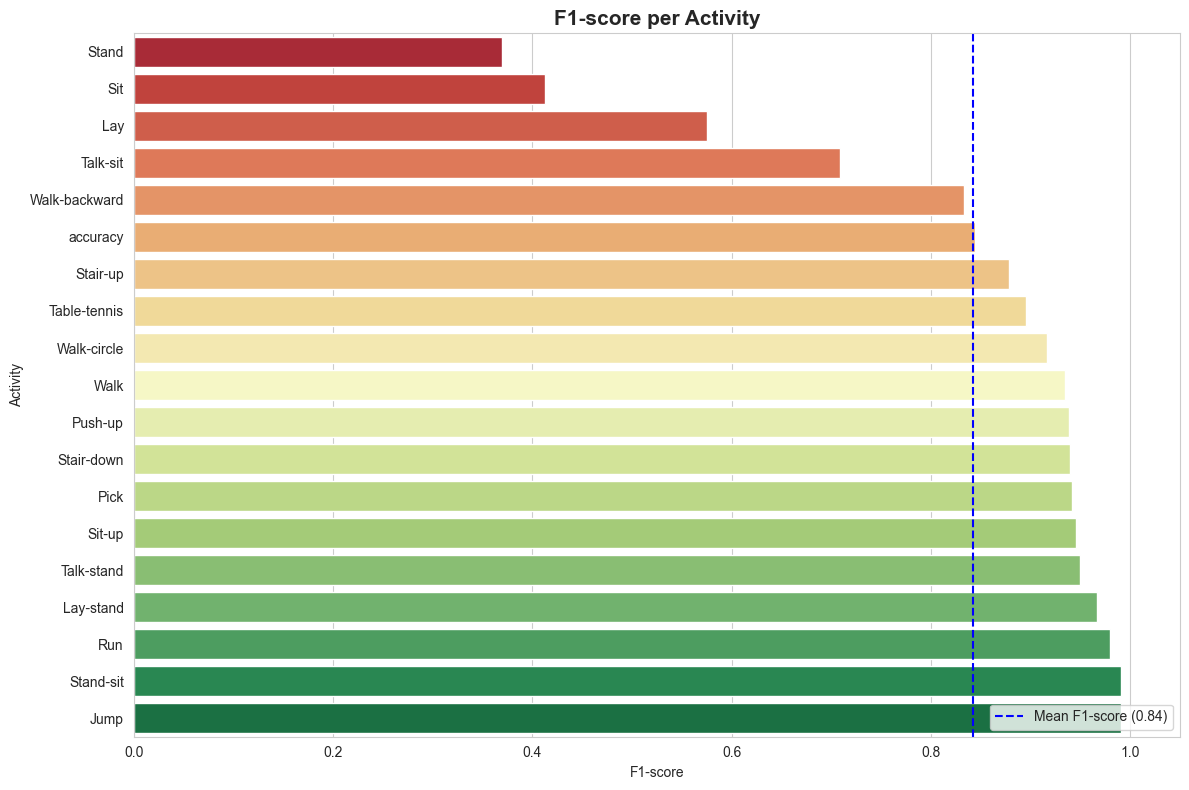

In [17]:
plot_class_performance(class_df, metric="f1-score")

### 2.1.2.2 Recall

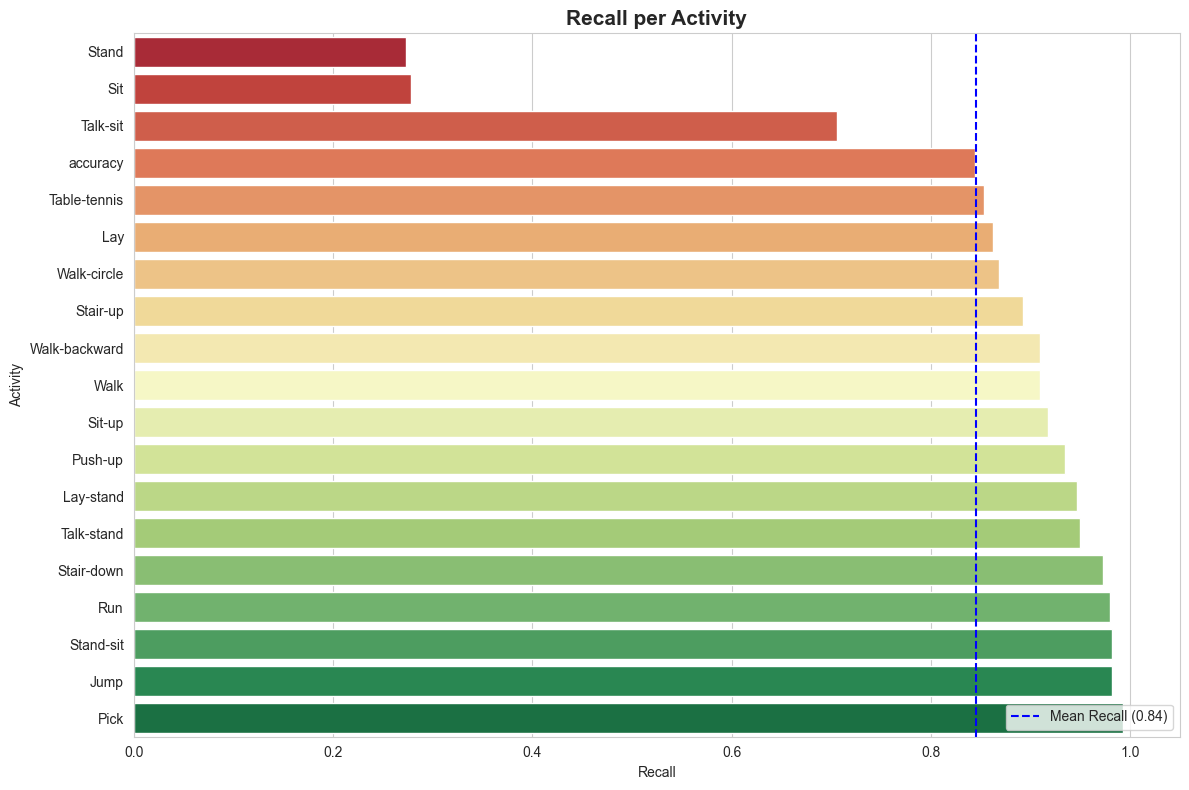

In [18]:
plot_class_performance(class_df, metric="recall")

### 2.1.2.3 Precision

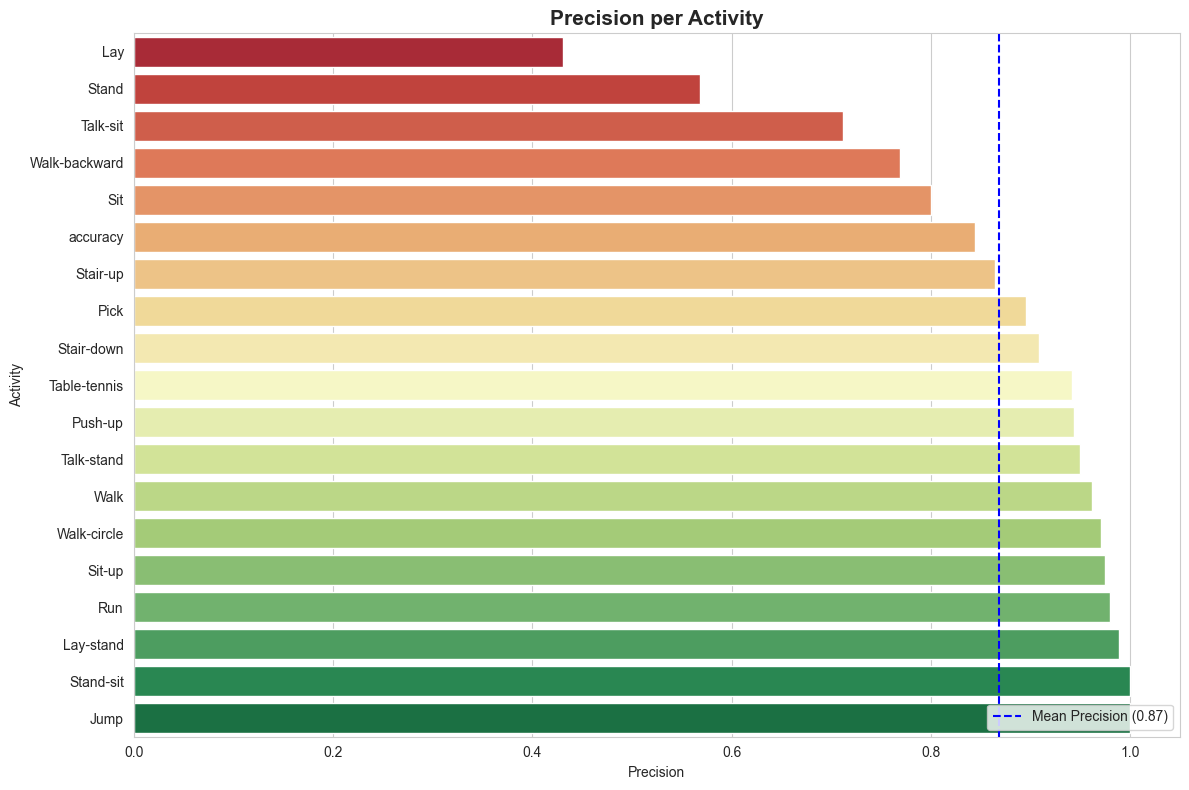

In [19]:
plot_class_performance(class_df, metric="precision")

### 2.1.2.4 Most confused classes by total misses

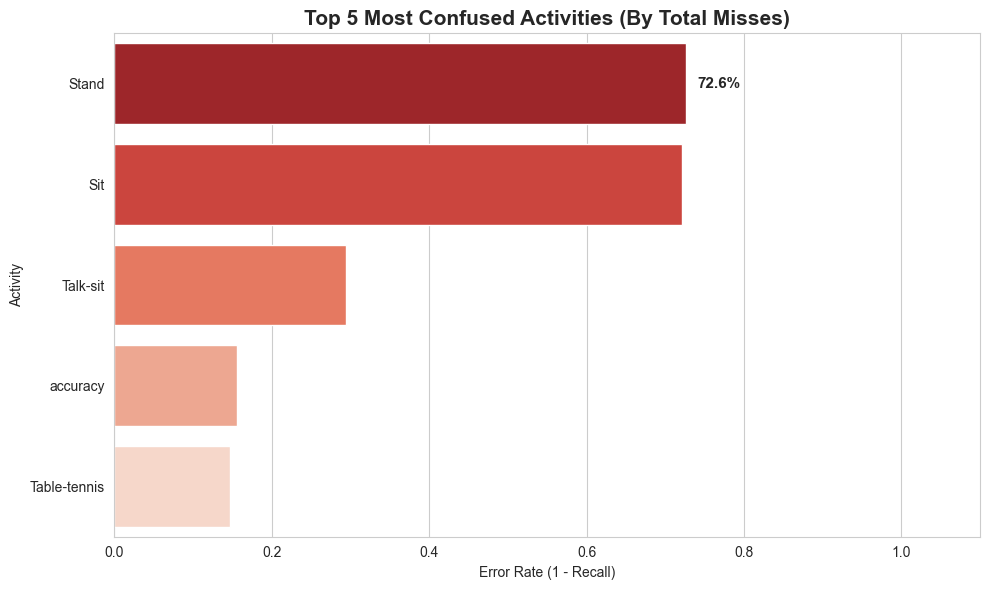

In [20]:
plot_most_confused_classes(class_df, top_n=5)

### 2.1.2.5 Top mutually confused classes

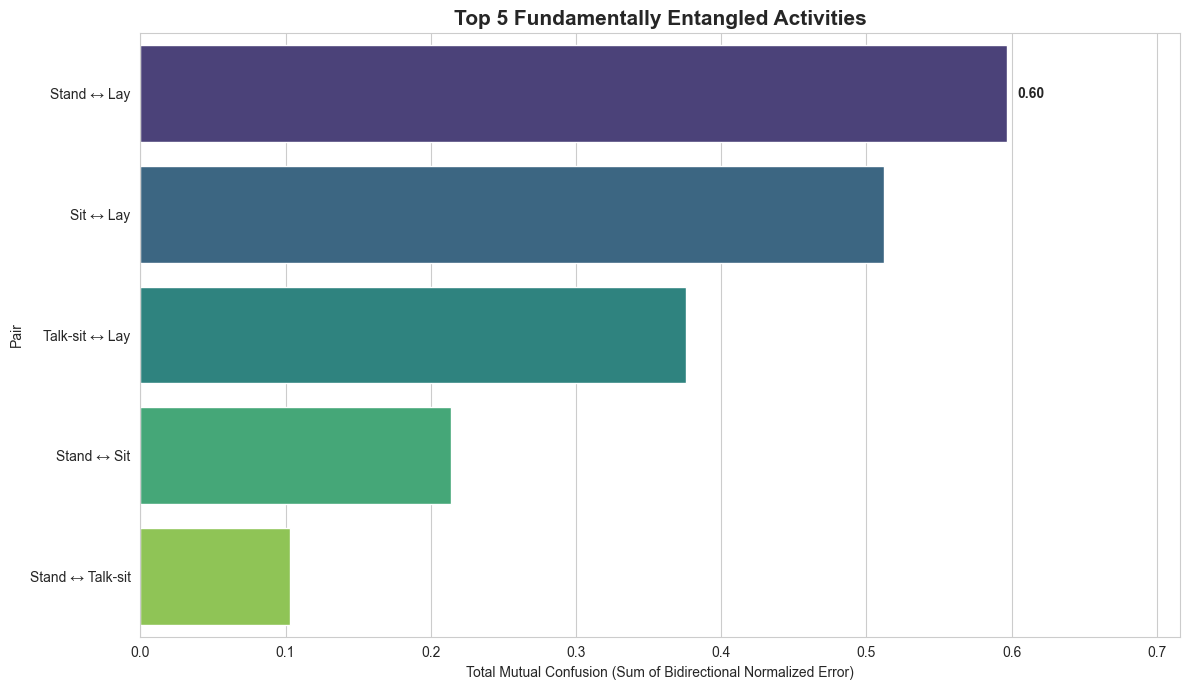

In [21]:
plot_top_mutual_confusions(Y_magnitude_test, predictions, activity_map, top_n=5)

# 3. Neural network evaluation (hybrid)

In [5]:
X_HYBRID, Y_HYBRID, LENGHTS_HYBRID, SCALER_HYBRID = prepare_har_dataset(dataset_path, mode="hybrid", shuffle=True)

In [6]:
X_temp, X_hybrid_test, Y_temp, Y_hybrid_test, lengths_temp, lengths_hybrid_test = train_test_split(
    X_HYBRID, Y_HYBRID, LENGHTS_HYBRID, test_size=0.2, random_state=2
)


X_hybrid_train, X_hybrid_val, Y_hybrid_train, Y_hybrid_val, lengths_hybrid_train, lengths_hybrid_val = train_test_split(
    X_temp, Y_temp, lengths_temp, test_size=0.25, random_state=2
)
labels_hybrid = [activity_map[i] for i in range(num_classes)]
Y_hybrid_train = np.eye(num_classes)[Y_hybrid_train.astype(int)]
Y_hybrid_val = np.eye(num_classes)[Y_hybrid_val.astype(int)]
Y_hybrid_test = np.eye(num_classes)[Y_hybrid_test.astype(int)]

In [7]:
model_hybrid = prepare_model(labels=labels_hybrid, scaler=SCALER_HYBRID)

history_hybrid, total_time = model_hybrid.fit(
    x_train=X_hybrid_train,
    y_train=Y_hybrid_train,
    x_val=X_hybrid_val,
    y_val=Y_hybrid_val,
    epochs=150,
    batch_size=128,
    verbose=2,
    mask=lengths_hybrid_train,
    val_mask=lengths_hybrid_val,
    lr_decay_epochs=30,
    lr_decay=0.75,
    early_stopping_patience=15,
    early_stopping_min_delta=1e-3,
)

model_hybrid.save(r"models\har_model_hybrid_v0.nnp")

Epoch 1/150, 30.50s/epoch - ETA: 01:15:45
Loss: 2.205202, Acc: 0.3257
Val Loss: 1.419121 - Val Acc: 0.5003
Epoch 3/150, 19.15s/epoch - ETA: 00:56:33
Loss: 1.100785, Acc: 0.5952
Val Loss: 0.882048 - Val Acc: 0.6619
Epoch 5/150, 19.81s/epoch - ETA: 00:52:40
Loss: 0.783358, Acc: 0.7044
Val Loss: 0.625812 - Val Acc: 0.7681
Epoch 7/150, 19.57s/epoch - ETA: 00:50:29
Loss: 0.615407, Acc: 0.7683
Val Loss: 0.563383 - Val Acc: 0.7948
Epoch 9/150, 19.70s/epoch - ETA: 00:49:01
Loss: 0.515959, Acc: 0.8060
Val Loss: 0.472961 - Val Acc: 0.8138
Epoch 11/150, 19.75s/epoch - ETA: 00:47:52
Loss: 0.450517, Acc: 0.8204
Val Loss: 0.422589 - Val Acc: 0.8253
Epoch 13/150, 19.61s/epoch - ETA: 00:46:47
Loss: 0.409419, Acc: 0.8360
Val Loss: 0.393300 - Val Acc: 0.8291
Epoch 15/150, 19.60s/epoch - ETA: 00:45:50
Loss: 0.368900, Acc: 0.8476
Val Loss: 0.357983 - Val Acc: 0.8372
Epoch 17/150, 19.38s/epoch - ETA: 00:44:56
Loss: 0.351231, Acc: 0.8492
Val Loss: 0.334600 - Val Acc: 0.8487
Epoch 19/150, 19.29s/epoch - ETA:

In [8]:
print(f"Total training time: {total_time:.2f} seconds")
for metric_name, values in history_hybrid.metrics.items():
    print(f"{metric_name}: {values}")

Total training time: 1786.77 seconds
train_loss: [2.205202102661133, 1.4036604166030884, 1.1007845401763916, 0.9117857813835144, 0.7833583354949951, 0.689755380153656, 0.6154065132141113, 0.563811182975769, 0.5159591436386108, 0.4843931198120117, 0.450517475605011, 0.43288537859916687, 0.40941891074180603, 0.3937380611896515, 0.3689001202583313, 0.3802732229232788, 0.3512309193611145, 0.323520302772522, 0.31671738624572754, 0.3069327771663666, 0.30917713046073914, 0.3134859800338745, 0.2934078574180603, 0.28561723232269287, 0.2853514850139618, 0.2790970802307129, 0.271976500749588, 0.2690899670124054, 0.258049875497818, 0.25795701146125793, 0.25897088646888733, 0.23911474645137787, 0.23022398352622986, 0.23887470364570618, 0.2298947423696518, 0.225249245762825, 0.22020527720451355, 0.22342130541801453, 0.22982297837734222, 0.22269314527511597, 0.2113669067621231, 0.2092112898826599, 0.20275795459747314, 0.2026928961277008, 0.19639238715171814, 0.19705459475517273, 0.1889684945344925, 0

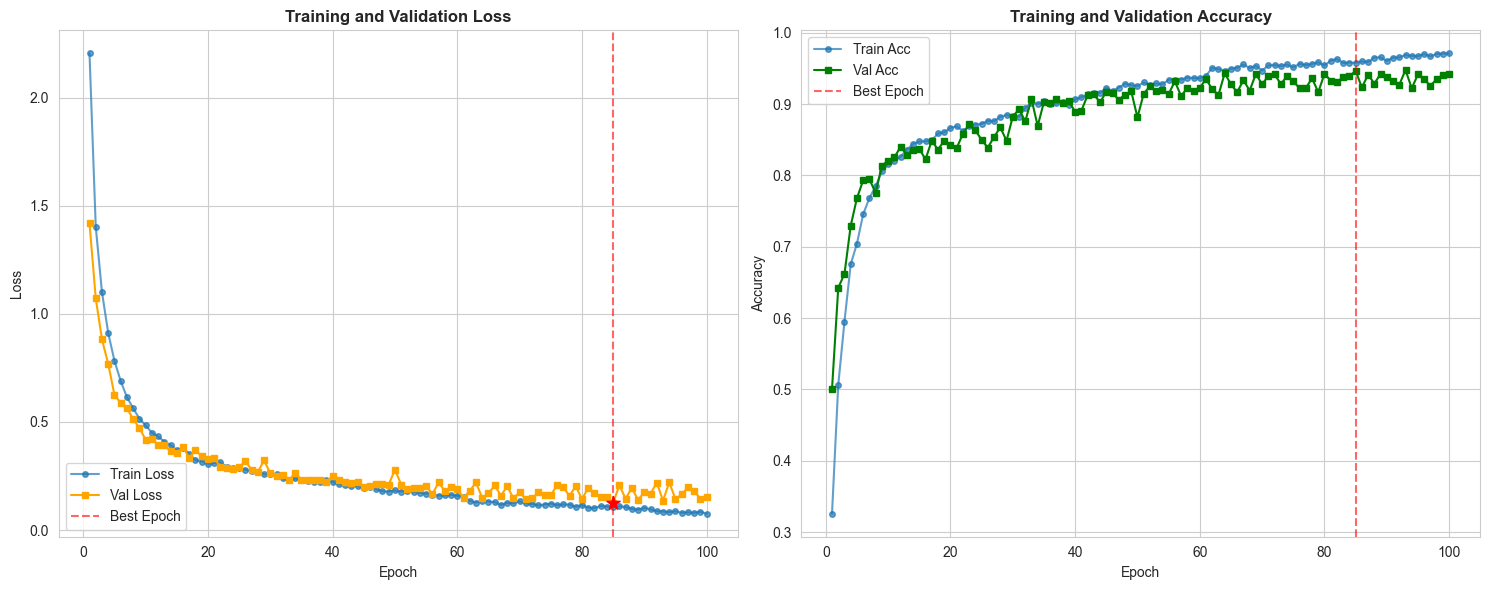

In [9]:
plot_training_history(history_hybrid)

## 3.1 Evaluation

### 3.1.1 Confisuion matrix

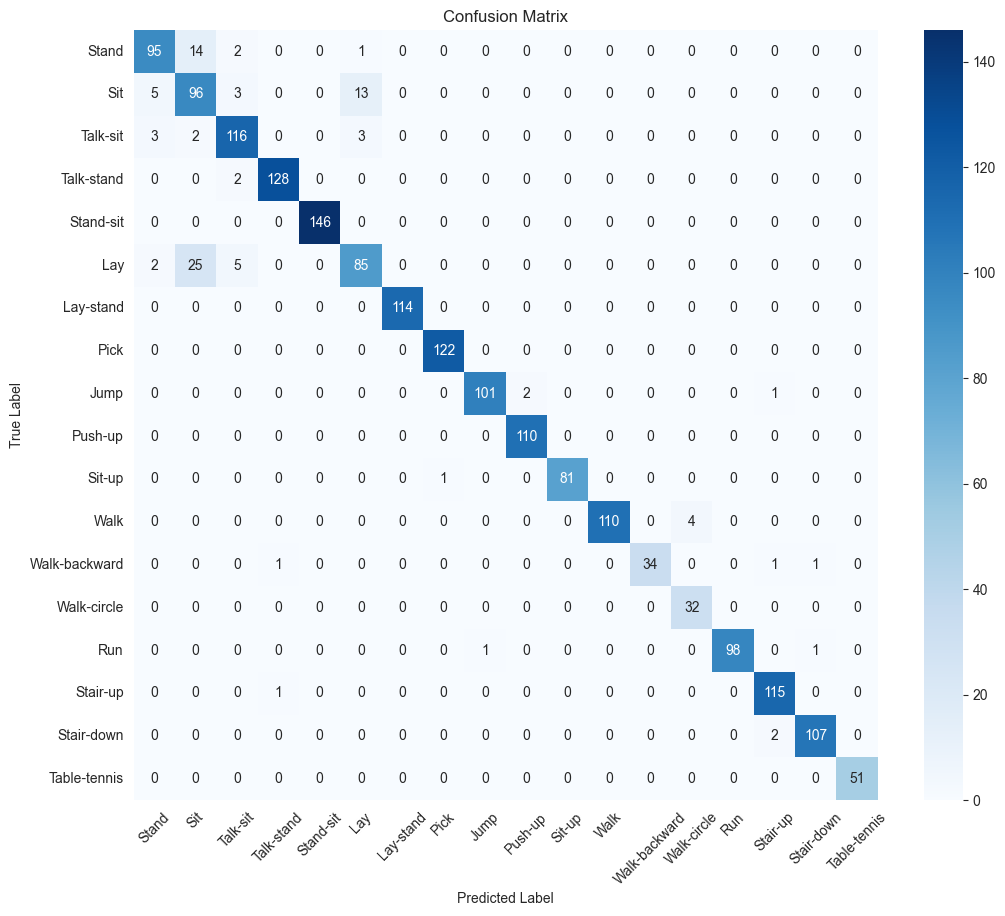

In [10]:
plot_confusion_matrix(
    X_hybrid_test,
    Y_hybrid_test,
    model_hybrid,
    lengths_test=lengths_hybrid_test,
    activity_map=model_hybrid.activity_labels,
)

### 3.1.2 Metrics per activity

In [11]:
predictions_hybrid = model_hybrid.predict(X_hybrid_test, mask=lengths_hybrid_test)
global_m_hybrid, class_df_hybrid = get_detailed_metrics(Y_hybrid_test, predictions_hybrid, activity_map)

### 3.1.2.1 F1-score

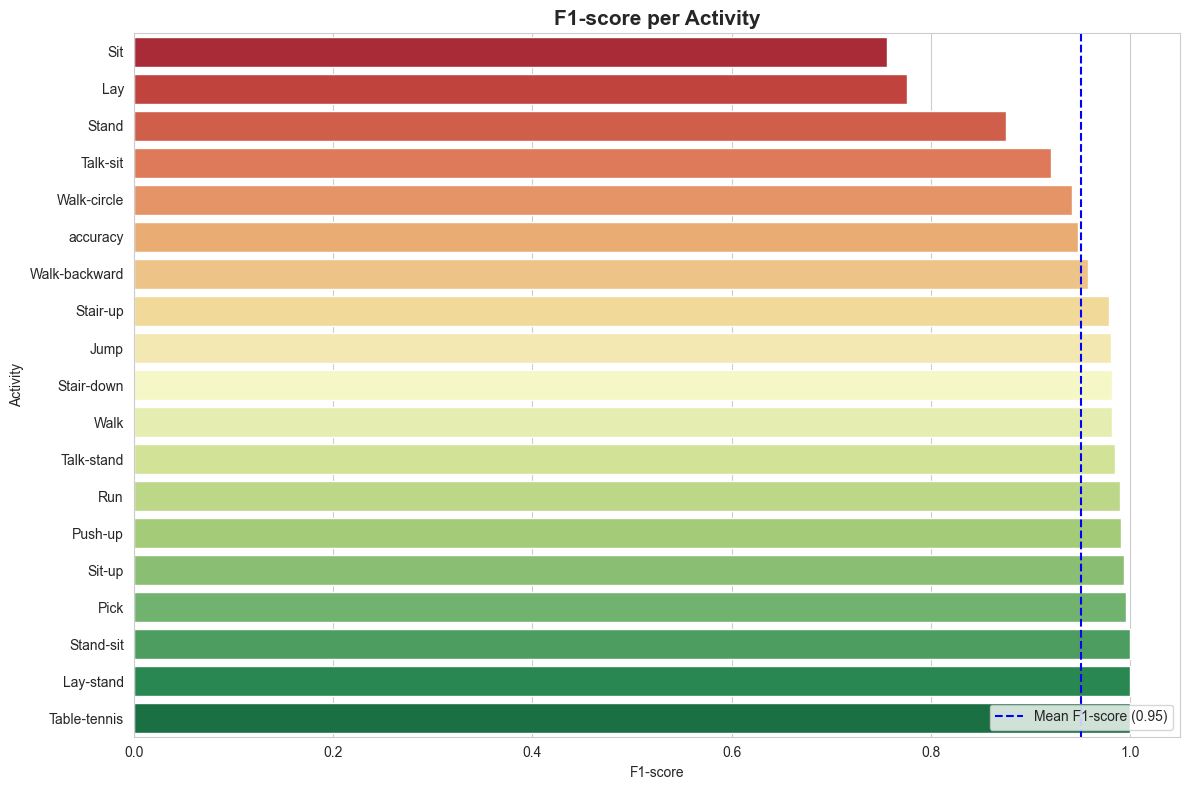

In [12]:
plot_class_performance(class_df_hybrid, metric="f1-score")

### 3.1.2.2 Recall

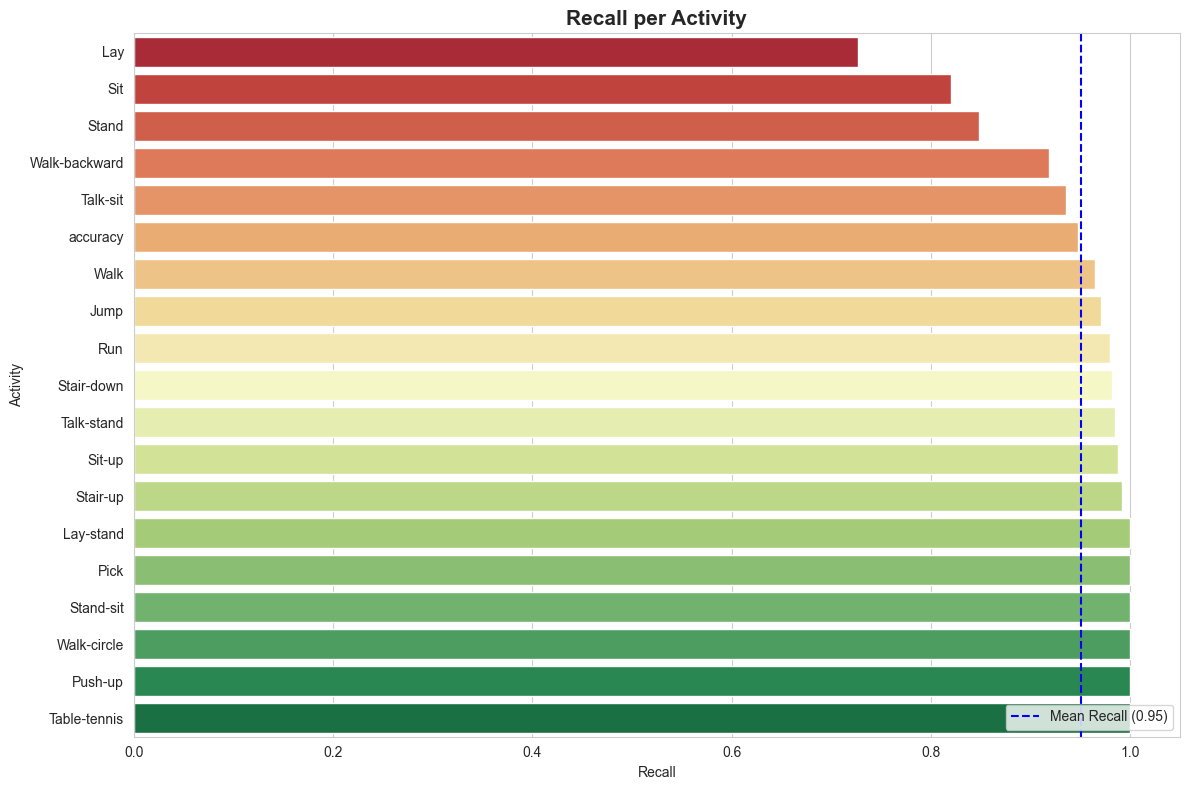

In [13]:
plot_class_performance(class_df_hybrid, metric="recall")

### 3.1.2.3 Precision

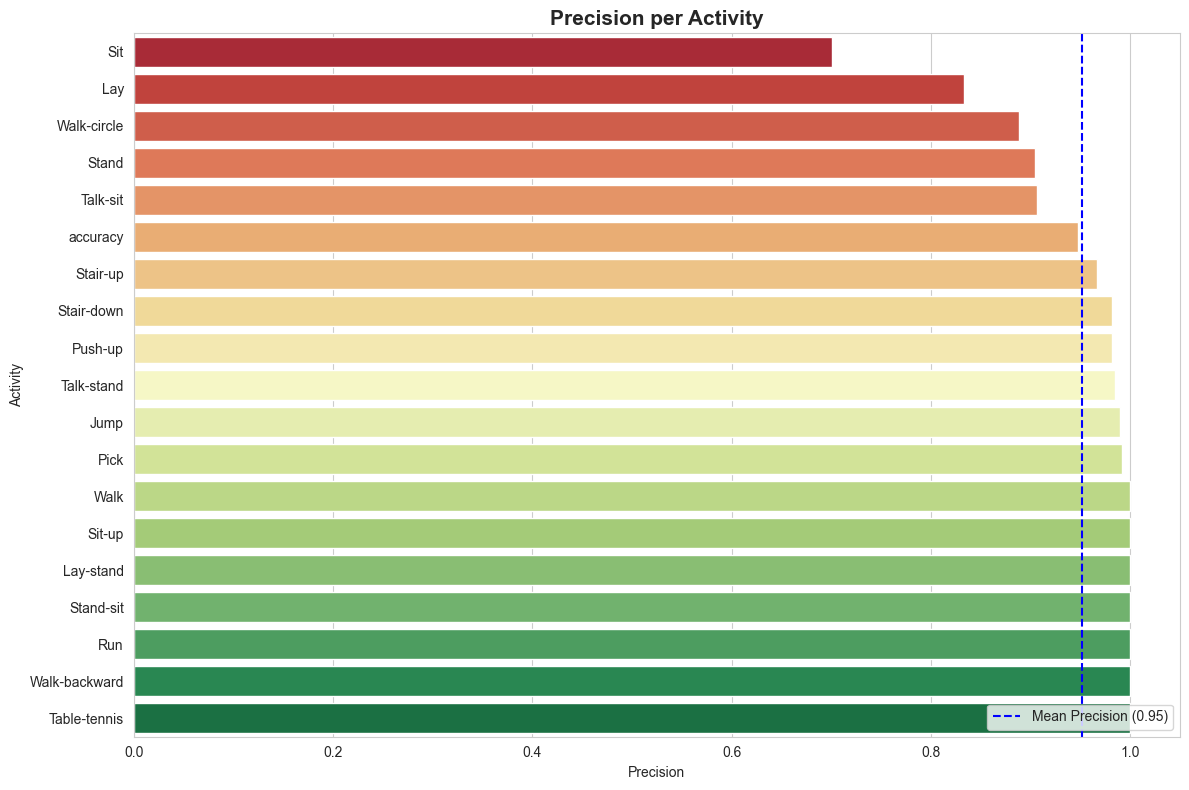

In [14]:
plot_class_performance(class_df_hybrid, metric="precision")

### 3.1.2.4 Most confused classes by total misses

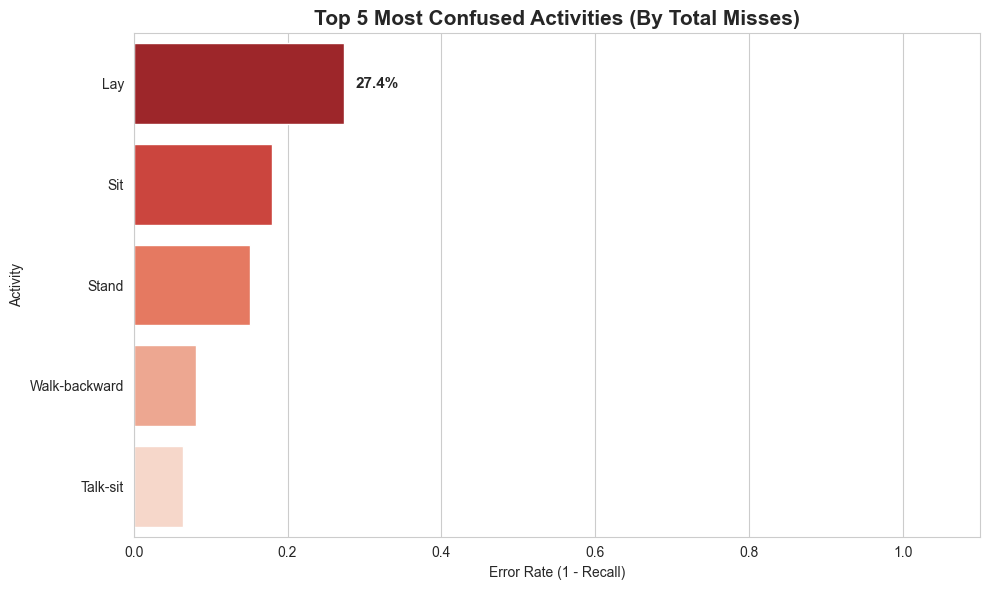

In [15]:
plot_most_confused_classes(class_df_hybrid, top_n=5)

### 3.1.2.5 Top mutually confused classes

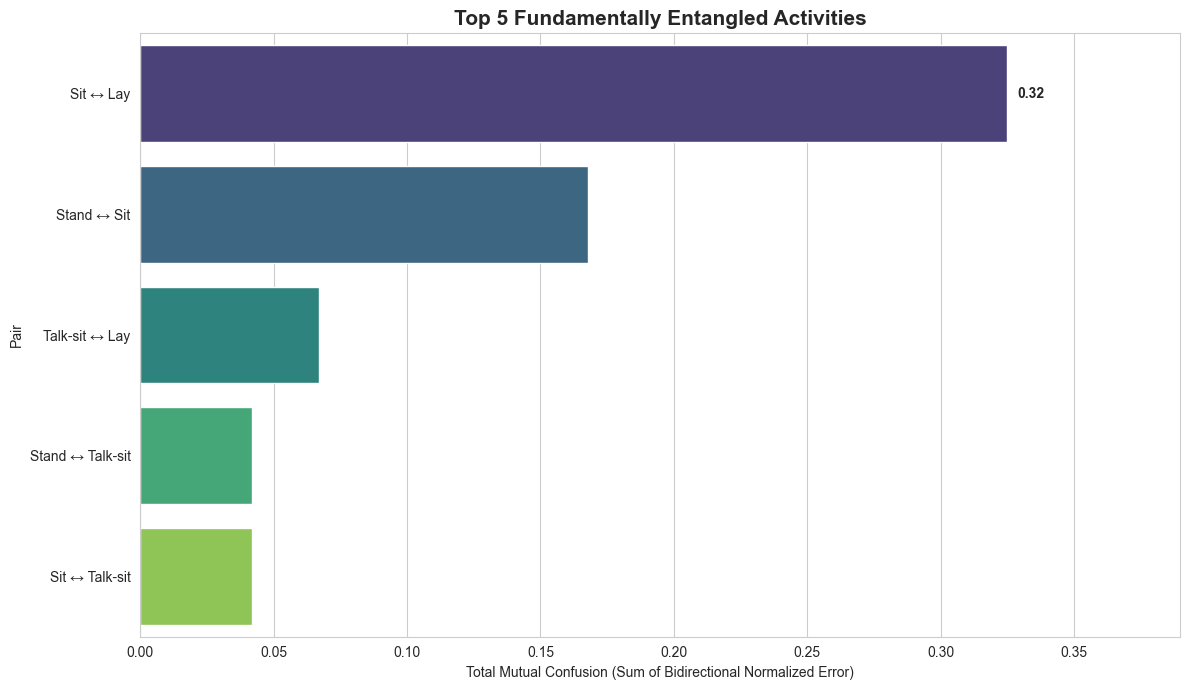

In [17]:
plot_top_mutual_confusions(Y_hybrid_test, predictions_hybrid, activity_map, top_n=5)

# 4. Comparsion of the three models - raw, magnitude, hybrid

In [5]:
model_raw: Sequential = Network.load(r"models\har_model_raw_v0.nnp")
model_mag: Sequential = Network.load(r"models\har_model_magnitude_v0.nnp")
model_hybrid: Sequential = Network.load(r"models\har_model_hybrid_v0.nnp")

In [6]:
X_raw, Y_raw, lengths_raw, _ = prepare_har_dataset(dataset_path, mode="raw", shuffle=False)
X_mag, Y_mag, lengths_mag, _ = prepare_har_dataset(dataset_path, mode="mag", shuffle=False)
X_hybrid, Y_hybrid, lengths_hybrid, _ = prepare_har_dataset(dataset_path, mode="hybrid", shuffle=False)

In [7]:
X_train_raw, X_test_raw, Y_train_raw, Y_test_raw, lengths_train_raw, lengths_test_raw = train_test_split(
    X_raw, Y_raw, lengths_raw, test_size=0.2, random_state=2
)
X_train_mag, X_test_mag, Y_train_mag, Y_test_mag, lengths_train_mag, lengths_test_mag = train_test_split(
    X_mag, Y_mag, lengths_mag, test_size=0.2, random_state=2
)
X_train_hybrid, X_test_hybrid, Y_train_hybrid, Y_test_hybrid, lengths_train_hybrid, lengths_test_hybrid = (
    train_test_split(X_hybrid, Y_hybrid, lengths_hybrid, test_size=0.2, random_state=2)
)

In [10]:
def to_one_hot(Y, num_classes):
    return np.eye(num_classes)[Y.astype(int)]


Y_train_raw = to_one_hot(Y_train_raw, num_classes)
Y_test_raw = to_one_hot(Y_test_raw, num_classes)
Y_train_mag = to_one_hot(Y_train_mag, num_classes)
Y_test_mag = to_one_hot(Y_test_mag, num_classes)
Y_train_hybrid = to_one_hot(Y_train_hybrid, num_classes)
Y_test_hybrid = to_one_hot(Y_test_hybrid, num_classes)

In [ ]:
def compare_models(model_list, test_data_list, activity_map):
    all_results = []
    class_comparison = []

    for (name, model), (x_t, y_t, l_t) in zip(model_list, test_data_list):
        print(f"Evaluating {name}...")
        preds = model.predict(x_t, mask=l_t)
        global_m, class_df = get_detailed_metrics(y_t, preds, activity_map)
        global_m["Model"] = name
        all_results.append(global_m)
        class_df["Model"] = name
        class_df["Activity"] = class_df.index
        class_comparison.append(class_df)
    report_df = pd.DataFrame(all_results).set_index("Model")
    comparison_df = pd.concat(class_comparison)
    return report_df, comparison_df


def plot_global_comparison(report_df):
    sns.set_style("whitegrid")
    plot_df = report_df.reset_index().melt(id_vars="Model", var_name="Metric", value_name="Score")
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="viridis")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10, fontweight="bold")
    plt.title("Models Comparison: Raw vs. Magnitude vs. Hybrid", fontsize=15, fontweight="bold")
    plt.ylim(0, 1.1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_class_wise_comparison(class_comp_df, metric="f1-score"):
    plt.figure(figsize=(15, 8))
    order = class_comp_df.groupby("Activity")[metric].mean().sort_values(ascending=False).index
    sns.barplot(data=class_comp_df, x="Activity", y=metric, hue="Model", order=order, palette="muted")
    plt.title(f"Per-Activity {metric.upper()} Comparison", fontsize=16, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric.capitalize())
    plt.ylim(0, 1.1)
    plt.legend(title="Data Approach")
    plt.tight_layout()
    plt.show()

### 4.1 Metrics comparison

In [11]:
models = [("Raw", model_raw), ("Magnitude", model_mag), ("Hybrid", model_hybrid)]
test_sets = [
    (X_test_raw, Y_test_raw, lengths_test_raw),
    (X_test_mag, Y_test_mag, lengths_test_mag),
    (X_test_hybrid, Y_test_hybrid, lengths_test_hybrid),
]

report, class_comp = compare_models(models, test_sets, activity_map)

Evaluating Raw...
Evaluating Magnitude...
Evaluating Hybrid...


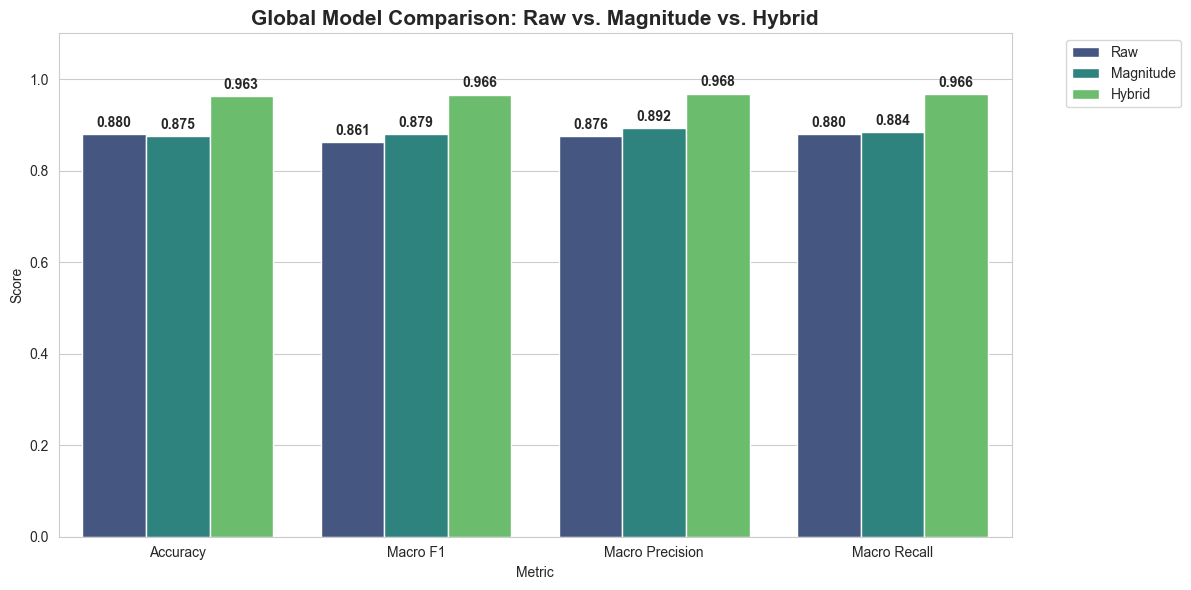

In [ ]:
plot_global_comparison(report)

               precision    recall  f1-score     support      Model  \
Stand           0.909091  0.256410  0.400000  117.000000        Raw   
Sit             0.000000  0.000000  0.000000  101.000000        Raw   
Talk-sit        0.648515  0.992424  0.784431  132.000000        Raw   
Talk-stand      0.991150  1.000000  0.995556  112.000000        Raw   
Stand-sit       0.994565  1.000000  0.997275  183.000000        Raw   
Lay             0.441048  0.878261  0.587209  115.000000        Raw   
Lay-stand       1.000000  0.972222  0.985915  108.000000        Raw   
Pick            0.964286  1.000000  0.981818  108.000000        Raw   
Jump            1.000000  0.989899  0.994924   99.000000        Raw   
Push-up         0.990385  0.980952  0.985646  105.000000        Raw   
Sit-up          0.977778  0.988764  0.983240   89.000000        Raw   
Walk            0.981481  0.972477  0.976959  109.000000        Raw   
Walk-backward   0.958333  1.000000  0.978723   46.000000        Raw   
Walk-c

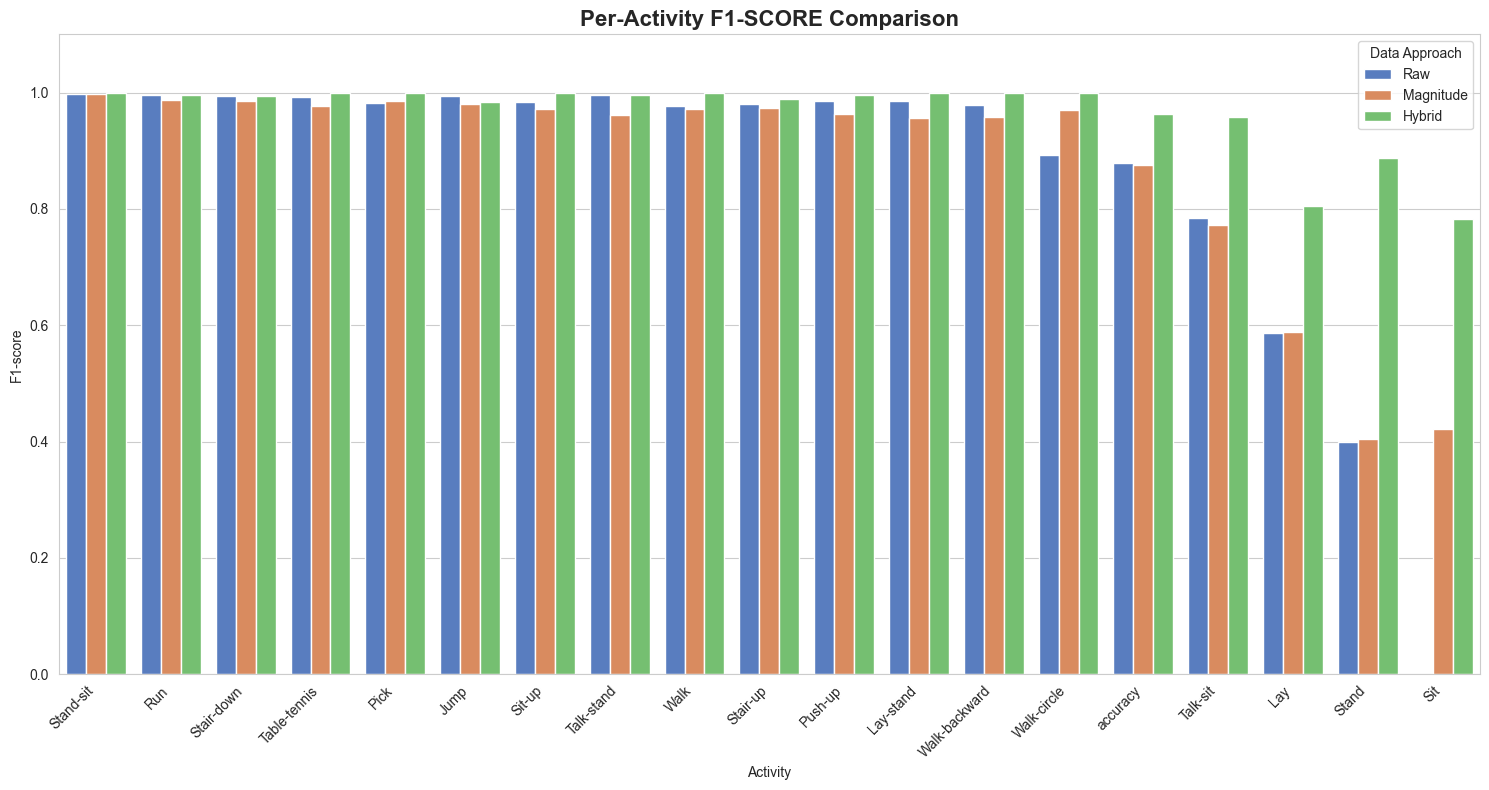

In [18]:
print(class_comp)
plot_class_wise_comparison(class_comp, metric="f1-score")

# CPU vs GPU performance

In [ ]:
def compare_gpu_vs_cpu(X, Y, model: Network, epochs=1, batch_size=64, verbose=5):
    if not backend._cupy_runtime_ok:
        print("GPU runtime not available. Skipping GPU vs CPU comparison.")
        return -1, -1
    backend.configure(policy=BackendPolicy(use_gpu=False), dataset_bytes=0)
    model.reset()
    X_cpu, Y_cpu = backend.asarray(X), backend.asarray(Y)
    _, cpu_time = model.fit(X_cpu, Y_cpu, epochs=epochs, batch_size=batch_size, verbose=verbose)
    model.reset()
    backend.configure(policy=BackendPolicy(use_gpu=True, min_gpu_bytes=0), dataset_bytes=10)
    X_gpu, Y_gpu = backend.asarray(X), backend.asarray(Y)
    _, gpu_time = model.fit(X_gpu, Y_gpu, epochs=epochs, batch_size=batch_size, verbose=verbose)
    return cpu_time, gpu_time


def plot_performance_benchmark(cpu_time, gpu_time):
    sns.set_style("whitegrid")
    plt.figure(figsize=(9, 6))

    devices = ["CPU (NumPy)", "GPU (CuPy)"]
    times = [cpu_time, gpu_time]
    speedup = cpu_time / gpu_time

    ax = sns.barplot(x=devices, y=times, palette=["#4C72B0", "#C44E52"], hue=devices, legend=False)

    ax.bar_label(ax.containers[0], fmt="%.2fs", padding=8, fontweight="bold", fontsize=12)

    props = {"boxstyle": "round", "facecolor": "white", "alpha": 0.9, "edgecolor": "gray"}
    plt.text(
        0.5,
        0.95,
        f"GPU Speedup: {speedup:.2f}x Faster",
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment="top",
        horizontalalignment="center",
        bbox=props,
        color="#C44E52",
        fontweight="bold",
    )

    plt.title("Hardware Acceleration Benchmark: CPU vs GPU", fontsize=15, pad=20)
    plt.ylabel("Total Execution Time (seconds)", fontsize=12)
    plt.ylim(0, max(times) * 1.2)
    plt.tight_layout()

2026-03-28 14:59:00,137 | INFO | src.backend | Using backend: numpy
Epoch 1/5, 74.09s/epoch - ETA: 00:04:56
Loss: 2.581080, Acc: 0.2279
Epoch 2/5, 75.72s/epoch - ETA: 00:03:44
Loss: 1.770375, Acc: 0.4286
Epoch 3/5, 74.33s/epoch - ETA: 00:02:29
Loss: 1.404784, Acc: 0.5300
Epoch 4/5, 79.66s/epoch - ETA: 00:01:15
Loss: 1.163664, Acc: 0.6021
Epoch 5/5, 76.20s/epoch - ETA: 00:00:00
Loss: 0.996498, Acc: 0.6512

Training Complete. Total Time: 00:06:20
2026-03-28 15:05:20,158 | INFO | src.backend | GPU requested. Dataset size: 10 bytes. Minimum for GPU: 0 bytes.
2026-03-28 15:05:20,159 | INFO | src.backend | CuPy available: True.
2026-03-28 15:05:20,159 | INFO | src.backend | Using backend: cupy
Epoch 1/5, 2.64s/epoch - ETA: 00:00:10
Loss: 2.669767, Acc: 0.2143
Epoch 2/5, 2.48s/epoch - ETA: 00:00:07
Loss: 1.800279, Acc: 0.4212
Epoch 3/5, 2.48s/epoch - ETA: 00:00:05
Loss: 1.422413, Acc: 0.5331
Epoch 4/5, 2.48s/epoch - ETA: 00:00:02
Loss: 1.164812, Acc: 0.5988
Epoch 5/5, 2.48s/epoch - ETA: 00:00

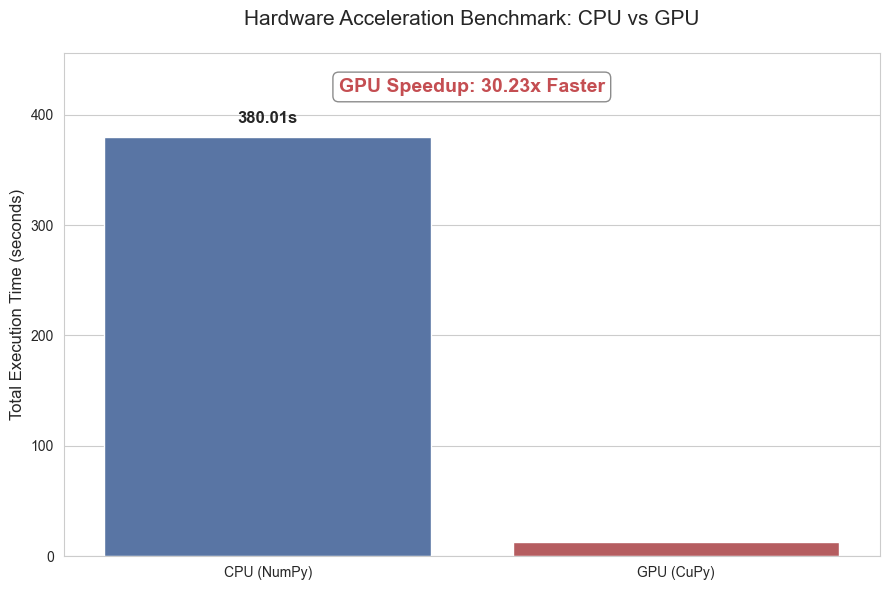

In [ ]:
X_RAW, Y_RAW, LENGHTS_RAW, SCALER_RAW = prepare_har_dataset(dataset_path, mode="raw", shuffle=True)
model_comparison_gpu_cpu = prepare_model(labels=labels_raw, scaler=SCALER_RAW)
cpu_time, gpu_time = compare_gpu_vs_cpu(
    X_raw_train, Y_raw_train, model_comparison_gpu_cpu, epochs=5, batch_size=256, verbose=1
)
print(f"CPU time: {cpu_time:.2f} seconds")
print(f"GPU time: {gpu_time:.2f} seconds")
print(f"Speedup: {cpu_time / gpu_time:.2f}x")
plot_performance_benchmark(cpu_time, gpu_time)